In [1]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
import matplotlib.pyplot as plt

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


In [3]:
model = models.resnet50(pretrained=False)
model.fc = nn.Linear(model.fc.in_features, 1)
model.load_state_dict(torch.load("models/saved_models/model.pth", map_location=device))
model = model.to(device)
model.eval()
model

i:\miniconda3\envs\ml\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
i:\miniconda3\envs\ml\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [4]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

Testing on 10 images from different age groups:

1_1_0_20161219225855568.jpg.chip.jpg               | Pred:   4.6 | True:   1 | Error:   3.6
8_1_0_20170109204954253.jpg.chip.jpg               | Pred:  32.1 | True:   8 | Error:  24.1
17_0_3_20170104225734512.jpg.chip.jpg              | Pred:  21.1 | True:  17 | Error:   4.1
13_0_0_20170104013342923.jpg.chip.jpg              | Pred:  21.5 | True:  13 | Error:   8.5
24_1_0_20170116214235749.jpg.chip.jpg              | Pred:  37.0 | True:  24 | Error:  13.0
27_0_1_20170116203636129.jpg.chip.jpg              | Pred:  26.4 | True:  27 | Error:   0.6
43_0_0_20170117185831058.jpg.chip.jpg              | Pred:  37.3 | True:  43 | Error:   5.7
50_0_4_20170117204204793.jpg.chip.jpg              | Pred:  44.8 | True:  50 | Error:   5.2
61_0_0_20170117174635328.jpg.chip.jpg              | Pred:  52.5 | True:  61 | Error:   8.5
56_1_0_20170120133230636.jpg.chip.jpg              | Pred:  34.4 | True:  56 | Error:  21.6


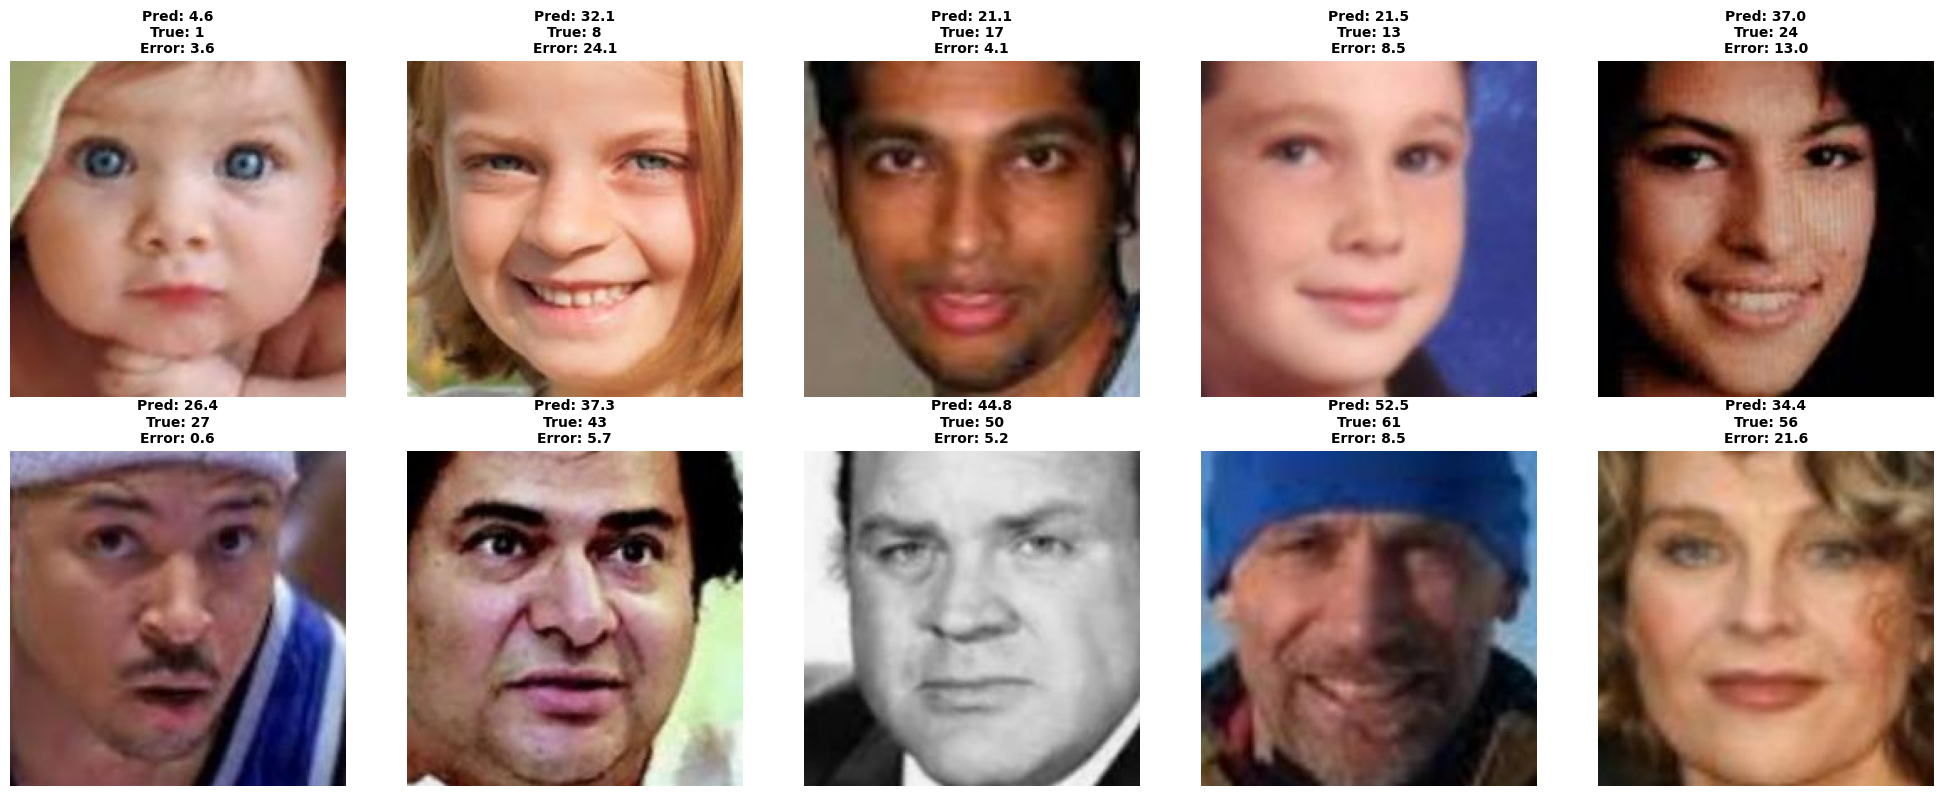

In [16]:
import random

image_folder = "data/dataset/UTKFace"
all_files = [f for f in os.listdir(image_folder) if f.endswith(".jpg")]

age_groups = {
    'Child (0-12)': [],
    'Teen (13-19)': [],
    'Young (20-35)': [],
    'Middle (36-55)': [],
    'Senior (56+)': []
}

for filename in all_files:
    age = int(filename.split("_")[0])
    if age <= 12:
        age_groups['Child (0-12)'].append(filename)
    elif age <= 19:
        age_groups['Teen (13-19)'].append(filename)
    elif age <= 35:
        age_groups['Young (20-35)'].append(filename)
    elif age <= 55:
        age_groups['Middle (36-55)'].append(filename)
    else:
        age_groups['Senior (56+)'].append(filename)

selected = []
for group_name, files in age_groups.items():
    selected.extend(random.sample(files, min(2, len(files))))

print(f"Testing on {len(selected)} images from different age groups:\n")

# Display results
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, img_name in enumerate(selected):
    img_path = os.path.join(image_folder, img_name)
    img = Image.open(img_path).convert("RGB")
    
    img_tensor = transform(img).unsqueeze(0).to(device)
    with torch.no_grad():
        pred = model(img_tensor).item()
    
    true_age = int(img_name.split("_")[0])
    error = abs(pred - true_age)
    
    axes[i].imshow(img)
    axes[i].axis("off")
    axes[i].set_title(
        f"Pred: {pred:.1f}\nTrue: {true_age}\nError: {error:.1f}",
        fontsize=10,
        fontweight='bold',
    )
    
    print(f"{img_name:50s} | Pred: {pred:5.1f} | True: {true_age:3d} | Error: {error:5.1f}")

plt.tight_layout()
plt.show()